## Generating Velocity Models from the OpenFWI Dataset Using GAN and VAE

Utilize both MLP and CNN GAN/VAE architectures to determine the optimal model for generating velocity models.

The notebook is the main program. Model definitions, data loading, training loops, metrics, and plotting helpers are stored in `.py` files and imported here.

### Project structure

- `assignment9_models.py`: MLP/CNN VAE and GAN model classes.
- `assignment9_utils.py`: efficient memory-mapped OpenFWI dataset, dataloaders, training functions, evaluation metrics, and plotting.
- `Assignment9.ipynb`: main experiment workflow.

In [9]:
import importlib
from pathlib import Path

import torch

import assignment9_models
import assignment9_utils

importlib.reload(assignment9_models)
importlib.reload(assignment9_utils)

from assignment9_models import (
    CNNDecoder,
    CNNDiscriminator,
    CNNEncoder,
    CNNGenerator,
    MLPDecoder,
    MLPDiscriminator,
    MLPEncoder,
    MLPGenerator,
    VAE,
)
from assignment9_utils import (
    OpenFWIVelocityDataset,
    create_loaders,
    evaluate_vae,
    plot_sample_sets,
    reference_batch,
    result_row,
    sample_gan,
    sample_vae,
    seed_everything,
    show_grid,
    train_gan,
    train_vae,
)

%matplotlib inline

SEED = 42
DATA_DIR = Path("model-20260504T122211Z-3-001") / "model"

# Keep the default small enough for CPU. Use None for all 60 files.
MAX_FILES = None
MAX_SAMPLES = None

IMG_SHAPE = (1, 70, 70)
IMG_DIM = 70 * 70
LATENT_DIM = 64
BATCH_SIZE = 64
VAE_EPOCHS = 10
GAN_EPOCHS = 10

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


### 1. Load OpenFWI velocity models

The data are read from `model-20260504T122211Z-3-001/model/*.npy`. Each file has shape `(500, 1, 70, 70)`. The custom dataset uses `np.load(..., mmap_mode='r')`, so it does not need to concatenate all files into memory.

{'data_dir': 'model-20260504T122211Z-3-001\\model', 'num_files': 60, 'first_file': 'model1.npy', 'last_file': 'model60.npy', 'num_samples': 30000, 'sample_shape': (1, 70, 70), 'velocity_min': 1500.0, 'velocity_max': 4500.0}
Train samples: 27000, validation samples: 3000


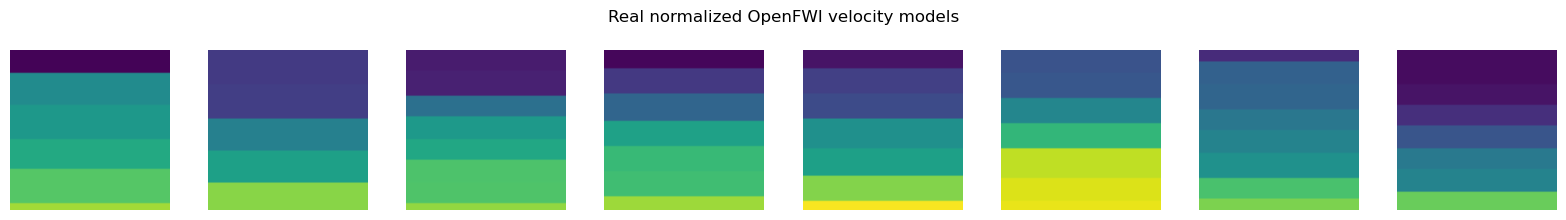

In [10]:
velocity_dataset = OpenFWIVelocityDataset(
    DATA_DIR,
    max_files=MAX_FILES,
    max_samples=MAX_SAMPLES,
)
train_loader, val_loader, train_dataset, val_dataset = create_loaders(
    velocity_dataset,
    batch_size=BATCH_SIZE,
    train_fraction=0.9,
    seed=SEED,
)
real_reference = reference_batch(velocity_dataset, n=512)

print(velocity_dataset.summary())
print(f"Train samples: {len(train_dataset)}, validation samples: {len(val_dataset)}")
show_grid(real_reference, "Real normalized OpenFWI velocity models")

### 2. MLP-VAE

This follows the Week 11 VAE logic: flatten the velocity model, encode it to latent mean/log-variance, sample using the reparameterization trick, then reconstruct with a decoder.

MLP-VAE epoch 01/10 | train loss 2820.212 | val mse 0.008507
MLP-VAE epoch 02/10 | train loss 2701.591 | val mse 0.007714
MLP-VAE epoch 03/10 | train loss 2685.824 | val mse 0.006365
MLP-VAE epoch 04/10 | train loss 2671.606 | val mse 0.005997
MLP-VAE epoch 05/10 | train loss 2665.897 | val mse 0.005767
MLP-VAE epoch 06/10 | train loss 2659.935 | val mse 0.005553
MLP-VAE epoch 07/10 | train loss 2651.600 | val mse 0.004914
MLP-VAE epoch 08/10 | train loss 2645.879 | val mse 0.004500
MLP-VAE epoch 09/10 | train loss 2642.006 | val mse 0.004273
MLP-VAE epoch 10/10 | train loss 2637.871 | val mse 0.003994
MLP-VAE finished in 0.4 min


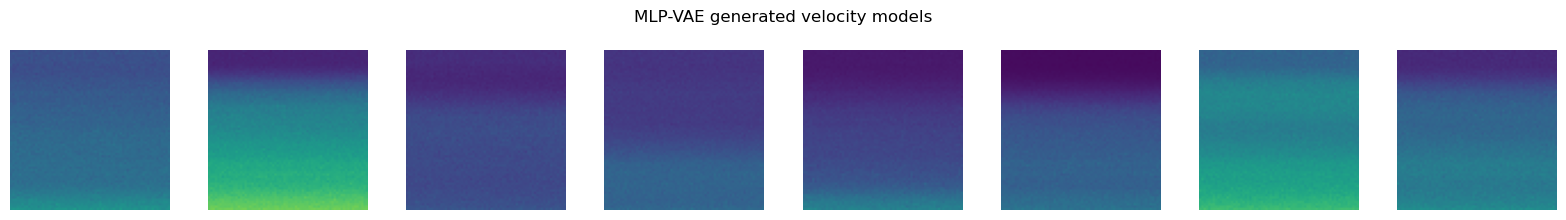

In [11]:
results = []

mlp_vae = VAE(
    MLPEncoder(input_dim=IMG_DIM, hidden_dim=512, latent_dim=LATENT_DIM),
    MLPDecoder(latent_dim=LATENT_DIM, hidden_dim=512, output_dim=IMG_DIM),
).to(device)

mlp_vae_history = train_vae(
    mlp_vae,
    train_loader,
    val_loader,
    device=device,
    epochs=VAE_EPOCHS,
    lr=1e-4,
    flatten=True,
    name="MLP-VAE",
)
mlp_vae_samples = sample_vae(mlp_vae, 128, LATENT_DIM, IMG_SHAPE, device=device, flatten=True)
mlp_vae_eval = evaluate_vae(mlp_vae, val_loader, device=device, flatten=True)
results.append(result_row("MLP-VAE", "VAE", real_reference, mlp_vae_samples, mlp_vae_eval))
show_grid(mlp_vae_samples, "MLP-VAE generated velocity models")

### 3. CNN-VAE

The CNN-VAE keeps the 2-D structure and usually preserves spatial continuity better than the MLP baseline.

CNN-VAE epoch 01/10 | train loss 3023.240 | val mse 0.005947
CNN-VAE epoch 02/10 | train loss 2645.176 | val mse 0.002889
CNN-VAE epoch 03/10 | train loss 2624.189 | val mse 0.002286
CNN-VAE epoch 04/10 | train loss 2616.949 | val mse 0.002053
CNN-VAE epoch 05/10 | train loss 2612.198 | val mse 0.001788
CNN-VAE epoch 06/10 | train loss 2608.585 | val mse 0.001588
CNN-VAE epoch 07/10 | train loss 2606.553 | val mse 0.001479
CNN-VAE epoch 08/10 | train loss 2605.317 | val mse 0.001463
CNN-VAE epoch 09/10 | train loss 2603.932 | val mse 0.001533
CNN-VAE epoch 10/10 | train loss 2603.085 | val mse 0.001422
CNN-VAE finished in 0.7 min


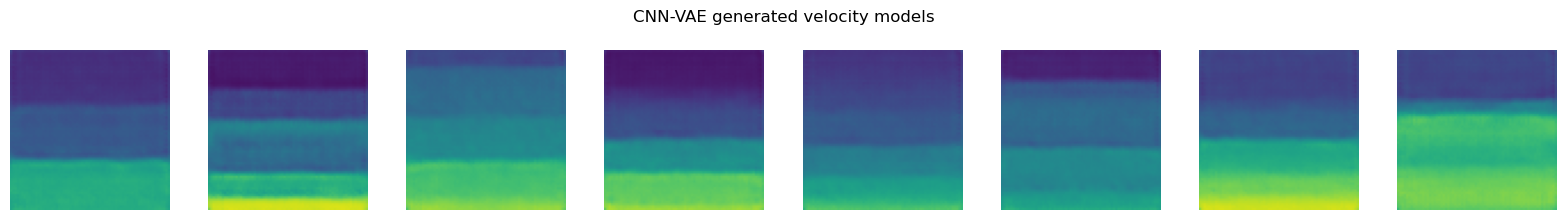

In [12]:
cnn_vae = VAE(
    CNNEncoder(latent_dim=LATENT_DIM, img_shape=IMG_SHAPE, base_channels=16),
    CNNDecoder(latent_dim=LATENT_DIM, img_shape=IMG_SHAPE, base_channels=16),
).to(device)

cnn_vae_history = train_vae(
    cnn_vae,
    train_loader,
    val_loader,
    device=device,
    epochs=VAE_EPOCHS,
    lr=1e-4,
    flatten=False,
    name="CNN-VAE",
)
cnn_vae_samples = sample_vae(cnn_vae, 128, LATENT_DIM, IMG_SHAPE, device=device, flatten=False)
cnn_vae_eval = evaluate_vae(cnn_vae, val_loader, device=device, flatten=False)
results.append(result_row("CNN-VAE", "VAE", real_reference, cnn_vae_samples, cnn_vae_eval))
show_grid(cnn_vae_samples, "CNN-VAE generated velocity models")

### 4. MLP-GAN

This follows the Week 12 GAN logic: the generator maps latent noise to velocity models, and the discriminator separates real models from generated ones. During GAN training, real images are scaled from `[0, 1]` to `[-1, 1]` to match the generator's `tanh` output.

MLP-GAN epoch 01/10 | D loss 0.5666 | G loss 0.8509
MLP-GAN epoch 02/10 | D loss 0.6382 | G loss 0.9321
MLP-GAN epoch 03/10 | D loss 0.6579 | G loss 0.8959
MLP-GAN epoch 04/10 | D loss 0.6572 | G loss 0.8951
MLP-GAN epoch 05/10 | D loss 0.6535 | G loss 0.9025
MLP-GAN epoch 06/10 | D loss 0.6614 | G loss 0.8770
MLP-GAN epoch 07/10 | D loss 0.6639 | G loss 0.8580
MLP-GAN epoch 08/10 | D loss 0.6678 | G loss 0.8565
MLP-GAN epoch 09/10 | D loss 0.6589 | G loss 0.8605
MLP-GAN epoch 10/10 | D loss 0.6681 | G loss 0.8566
MLP-GAN finished in 0.6 min


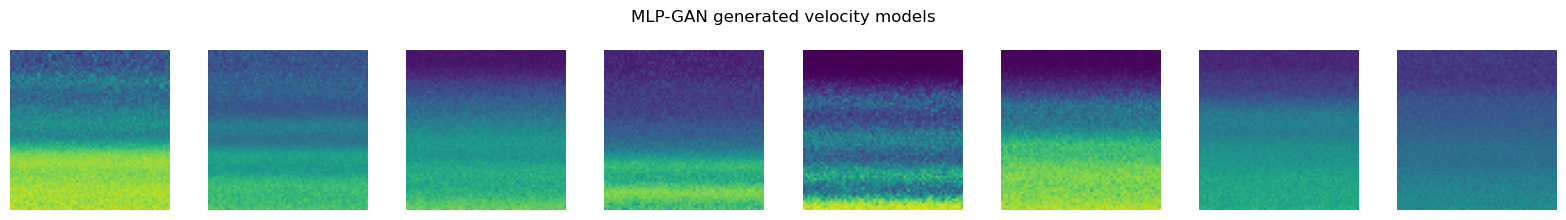

In [13]:
mlp_generator = MLPGenerator(LATENT_DIM, IMG_SHAPE).to(device)
mlp_discriminator = MLPDiscriminator(IMG_SHAPE).to(device)

mlp_gan_history = train_gan(
    mlp_generator,
    mlp_discriminator,
    train_loader,
    device=device,
    epochs=GAN_EPOCHS,
    lr=2e-4,
    latent_dim=LATENT_DIM,
    name="MLP-GAN",
)
mlp_gan_samples = sample_gan(mlp_generator, 128, LATENT_DIM, device=device)
results.append(result_row("MLP-GAN", "GAN", real_reference, mlp_gan_samples, mlp_gan_history[-1]))
show_grid(mlp_gan_samples, "MLP-GAN generated velocity models")

### 5. CNN-GAN

The CNN-GAN uses convolutional and transposed-convolutional layers so the generated velocity models are learned as images rather than flattened vectors.

CNN-GAN epoch 01/10 | D loss 0.2706 | G loss 2.8628
CNN-GAN epoch 02/10 | D loss 0.2548 | G loss 2.8907
CNN-GAN epoch 03/10 | D loss 0.2150 | G loss 3.6037
CNN-GAN epoch 04/10 | D loss 0.1787 | G loss 4.6521
CNN-GAN epoch 05/10 | D loss 0.2142 | G loss 4.1291
CNN-GAN epoch 06/10 | D loss 0.1879 | G loss 4.3951
CNN-GAN epoch 07/10 | D loss 0.1803 | G loss 5.3667
CNN-GAN epoch 08/10 | D loss 0.1728 | G loss 4.8932
CNN-GAN epoch 09/10 | D loss 0.1699 | G loss 5.7403
CNN-GAN epoch 10/10 | D loss 0.1793 | G loss 5.4437
CNN-GAN finished in 0.9 min


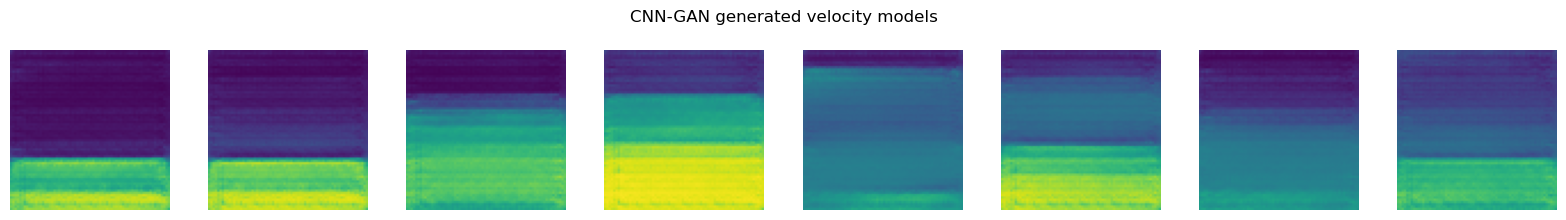

In [14]:
cnn_generator = CNNGenerator(LATENT_DIM, img_shape=IMG_SHAPE, base_channels=16).to(device)
cnn_discriminator = CNNDiscriminator(IMG_SHAPE, base_channels=16).to(device)

cnn_gan_history = train_gan(
    cnn_generator,
    cnn_discriminator,
    train_loader,
    device=device,
    epochs=GAN_EPOCHS,
    lr=2e-4,
    latent_dim=LATENT_DIM,
    name="CNN-GAN",
)
cnn_gan_samples = sample_gan(cnn_generator, 128, LATENT_DIM, device=device)
results.append(result_row("CNN-GAN", "GAN", real_reference, cnn_gan_samples, cnn_gan_history[-1]))
show_grid(cnn_gan_samples, "CNN-GAN generated velocity models")

### 6. Compare models and select the best generator

`generation_score` compares generated models with real velocity models using value statistics, histogram distance, and spatial-gradient statistics. Lower is better. For VAEs, `val_mse` is an additional reconstruction metric.

,model,family,generation_score,stats_error,hist_error,grad_error,val_loss,val_mse,epoch,d_loss,g_loss
0,CNN-VAE,VAE,0.028680,0.011219,0.006491,0.010970,2607.515876,0.001415,NaN,NaN,NaN
1,CNN-GAN,GAN,0.031843,0.012995,0.007808,0.011040,NaN,NaN,10.0,0.179292,5.443690
2,MLP-GAN,GAN,0.048641,0.005522,0.005395,0.037724,NaN,NaN,10.0,0.668086,0.856578
3,MLP-VAE,VAE,0.108828,0.077877,0.016271,0.014680,2640.280344,0.003975,NaN,NaN,NaN


Best model by generation_score: CNN-VAE (score=0.028680)


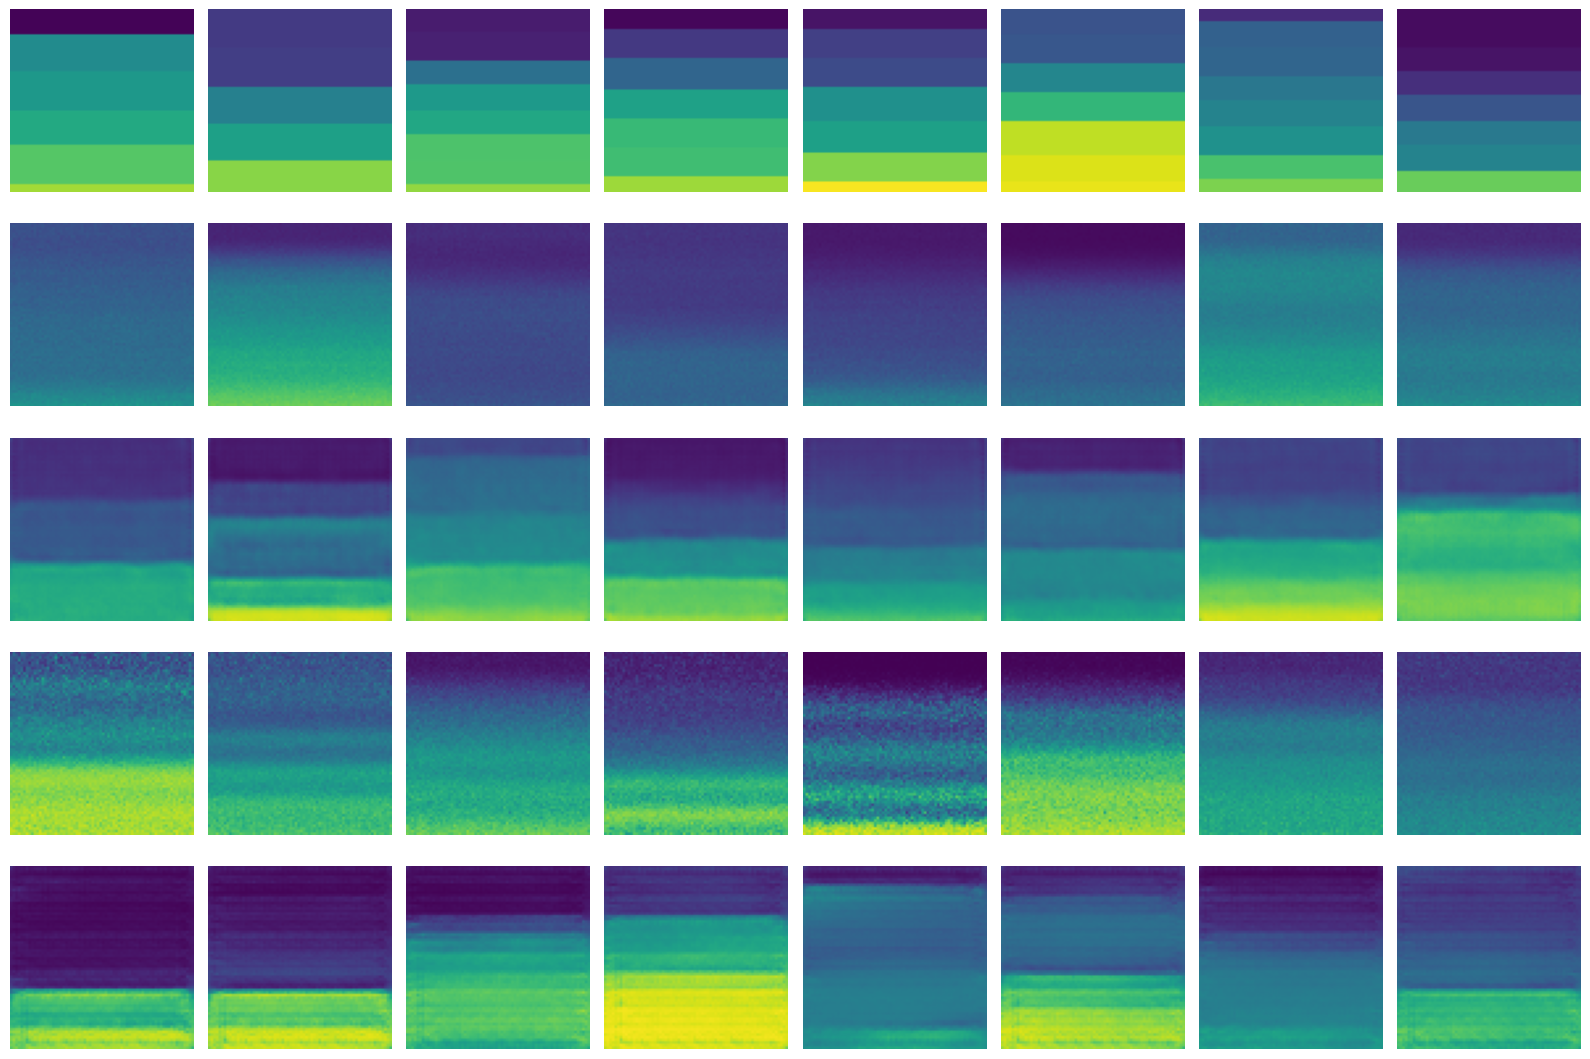

Interpretation:
- MLP models are direct lab baselines but flatten the velocity image.
- CNN models preserve local spatial continuity and are usually better for velocity-model images.
- VAEs train more stably and give reconstruction MSE; GANs can generate sharper images but are more sensitive to training length.
- The best model for this run is selected by the lowest generation_score and then checked visually in the grid.


In [15]:
try:
    import pandas as pd
except ImportError:
    pd = None

if pd is not None:
    results_df = pd.DataFrame(results).sort_values("generation_score").reset_index(drop=True)
    display(results_df)
    best = results_df.iloc[0]
    print(f"Best model by generation_score: {best['model']} (score={best['generation_score']:.6f})")
else:
    results_sorted = sorted(results, key=lambda row: row["generation_score"])
    for row in results_sorted:
        print(row)
    best = results_sorted[0]
    print(f"Best model by generation_score: {best['model']} (score={best['generation_score']:.6f})")

plot_sample_sets(
    [
        ("Real", real_reference[:8]),
        ("MLP-VAE", mlp_vae_samples[:8]),
        ("CNN-VAE", cnn_vae_samples[:8]),
        ("MLP-GAN", mlp_gan_samples[:8]),
        ("CNN-GAN", cnn_gan_samples[:8]),
    ],
    n=8,
)

print("Interpretation:")
print("- MLP models are direct lab baselines but flatten the velocity image.")
print("- CNN models preserve local spatial continuity and are usually better for velocity-model images.")
print("- VAEs train more stably and give reconstruction MSE; GANs can generate sharper images but are more sensitive to training length.")
print("- The best model for this run is selected by the lowest generation_score and then checked visually in the grid.")